# SentimentScope: Movie Review Sentiment Analysis

This notebook loads IMDB reviews, explores the data, defines a custom PyTorch Dataset and Transformer classifier, trains the model, and evaluates it on the complete held-out test set.

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from train import load_imdb
%matplotlib inline
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
print('Imports and reproducibility setup complete.')

Imports and reproducibility setup complete.


In [2]:
train_df, test_df = load_imdb('.', max_samples=None)
assert train_df.shape == (25000, 2)
assert test_df.shape == (25000, 2)
print('Training shape:', train_df.shape)
print('Testing shape:', test_df.shape)
print('Dataset shape assertions passed.')
display(train_df.head())

Training shape: (25000, 2)
Testing shape: (25000, 2)
Dataset shape assertions passed.


,review,label
0,Bromwell High is a cartoon comedy. It ran at t...,1
1,Homelessness (or Houselessness as George Carli...,1
2,Brilliant over-acting by Lesley Ann Warren. Be...,1
3,This is easily the most underrated film inn th...,1
4,This is not the typical Mel Brooks film. It wa...,1


## Data analysis and visualizations

In [3]:
train_df['review_length'] = train_df['review'].str.len()
print('Class distribution:')
display(train_df['label'].value_counts().sort_index())
print('Review-length statistics (characters):')
display(train_df['review_length'].describe())
print('Review length by sentiment:')
display(train_df.groupby('label')['review_length'].agg(['count', 'mean', 'median', 'min', 'max']))

Class distribution:


label
0    12500
1    12500
Name: count, dtype: int64

Review-length statistics (characters):


count    25000.00000
mean      1325.06964
std       1003.13367
min         52.00000
25%        702.00000
50%        979.00000
75%       1614.00000
max      13704.00000
Name: review_length, dtype: float64

Review length by sentiment:


,count,mean,median,min,max
label,,,,,
0,12500,1302.97904,976.5,52,8969
1,12500,1347.16024,982.0,70,13704


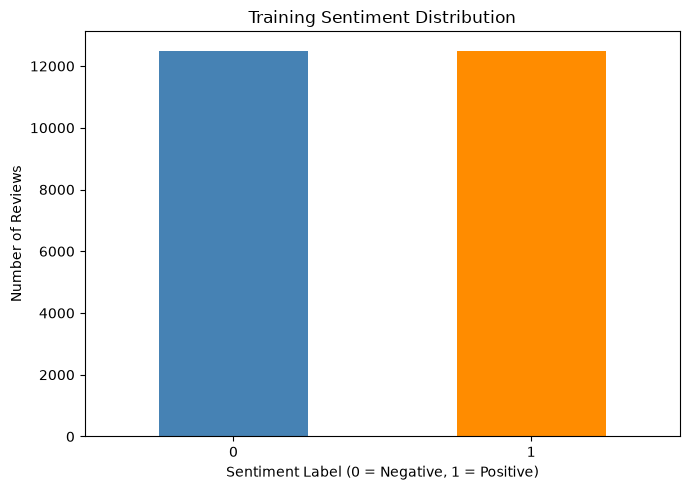

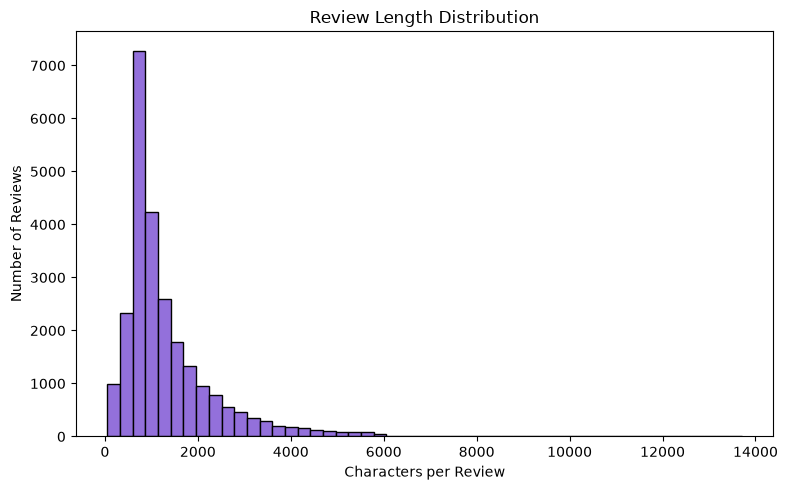

In [4]:
plt.figure(figsize=(7, 5))
train_df['label'].value_counts().sort_index().plot(kind='bar', color=['steelblue', 'darkorange'])
plt.title('Training Sentiment Distribution')
plt.xlabel('Sentiment Label (0 = Negative, 1 = Positive)')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 5))
train_df['review_length'].plot(kind='hist', bins=50, color='mediumpurple', edgecolor='black')
plt.title('Review Length Distribution')
plt.xlabel('Characters per Review')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

## Tokenization and custom PyTorch Dataset

In [5]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
sample_reviews = train_df['review'].sample(1000, random_state=42)
raw_token_lengths = [len(tokenizer.tokenize(text)) + 2 for text in sample_reviews]
print('Raw token-length statistics from 1,000 sampled reviews:')
display(pd.Series(raw_token_lengths).describe())
print('Percentage exceeding 128 tokens:', (pd.Series(raw_token_lengths) > 128).mean() * 100, '%')
token_lengths = [len(tokenizer(text, add_special_tokens=True, truncation=True, max_length=128)['input_ids']) for text in sample_reviews]
print('Token-length statistics after truncation to 128:')
display(pd.Series(token_lengths).describe())
train_part, val_part = train_test_split(train_df, test_size=0.1, random_state=42, stratify=train_df['label'])
class IMDBDataset(Dataset):
    def __init__(self, data, tokenizer, max_length=128):
        self.data = data.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.input_ids = tokenizer(self.data['review'].tolist(), padding='max_length', truncation=True, max_length=max_length, return_tensors='pt')['input_ids']
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        label = int(self.data.iloc[idx]['label'])
        return self.input_ids[idx], label

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (583 > 512). Running this sequence through the model will result in indexing errors


Raw token-length statistics from 1,000 sampled reviews:


count    1000.000000
mean      303.643000
std       232.138062
min        36.000000
25%       165.000000
50%       225.000000
75%       361.000000
max      1554.000000
dtype: float64

Percentage exceeding 128 tokens: 88.0 %


Token-length statistics after truncation to 128:


count    1000.000000
mean      123.463000
std        14.496578
min        36.000000
25%       128.000000
50%       128.000000
75%       128.000000
max       128.000000
dtype: float64

In [6]:
max_length = 128
train_dataset = IMDBDataset(train_part, tokenizer, max_length)
val_dataset = IMDBDataset(val_part, tokenizer, max_length)
test_dataset = IMDBDataset(test_df, tokenizer, max_length)
assert len(train_dataset) == 22500
assert len(val_dataset) == 2500
assert len(test_dataset) == 25000
sample_input_ids, sample_label = train_dataset[0]
assert isinstance(sample_input_ids, torch.Tensor)
assert sample_input_ids.shape == (max_length,)
assert isinstance(sample_label, int)
print('Training dataset length:', len(train_dataset))
print('Validation dataset length:', len(val_dataset))
print('Test dataset length:', len(test_dataset))
print('Input IDs shape:', sample_input_ids.shape)
print('Label type:', type(sample_label))
print('Dataset assertions passed.')

Training dataset length: 22500
Validation dataset length: 2500
Test dataset length: 25000
Input IDs shape: torch.Size([128])
Label type: <class 'int'>
Dataset assertions passed.


## Transformer model for binary classification

In [7]:
config = {'vocabulary_size': tokenizer.vocab_size, 'context_size': max_length, 'embedding_dim': 64, 'num_heads': 2, 'num_layers': 1, 'num_classes': 2, 'dropout': 0.1}
class DemoGPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.token_embedding = nn.Embedding(config['vocabulary_size'], config['embedding_dim'])
        self.position_embedding = nn.Embedding(config['context_size'], config['embedding_dim'])
        encoder_layer = nn.TransformerEncoderLayer(d_model=config['embedding_dim'], nhead=config['num_heads'], dropout=config['dropout'], batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=config['num_layers'])
        self.layer_norm = nn.LayerNorm(config['embedding_dim'])
        self.classifier = nn.Linear(config['embedding_dim'], config['num_classes'])
    def forward(self, input_ids):
        positions = torch.arange(input_ids.size(1), device=input_ids.device)
        x = self.token_embedding(input_ids) + self.position_embedding(positions)[None, :, :]
        x = self.layer_norm(self.transformer(x))
        return self.classifier(x.mean(dim=1))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DemoGPT(config).to(device)
dummy_input = torch.randint(0, config['vocabulary_size'], (32, config['context_size'])).to(device)
dummy_output = model(dummy_input)
print('Dummy output shape:', dummy_output.shape)
assert dummy_output.shape == (32, config['num_classes'])
print('DemoGPT shape assertion passed.')

Dummy output shape: torch.Size([32, 2])
DemoGPT shape assertion passed.


In [8]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)
print('DataLoaders created.')

DataLoaders created.


In [9]:
def calculate_accuracy(model, data_loader, device):
    model.eval()
    total_correct = 0
    total_samples = 0
    with torch.no_grad():
        for input_ids, labels in data_loader:
            logits = model(input_ids.to(device))
            predictions = logits.argmax(dim=1)
            total_correct += (predictions == labels.to(device)).sum().item()
            total_samples += labels.size(0)
    return 100.0 * total_correct / total_samples

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
epochs = 5
training_history = []
for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    for input_ids, labels in train_loader:
        input_ids, labels = input_ids.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(input_ids)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    epoch_loss = total_loss / len(train_loader)
    val_accuracy = calculate_accuracy(model, val_loader, device)
    training_history.append({'epoch': epoch + 1, 'loss': epoch_loss, 'validation_accuracy': val_accuracy})
    print(f'Epoch {epoch + 1}/{epochs} | Loss: {epoch_loss:.4f} | Val Accuracy: {val_accuracy:.2f}%')

Epoch 1/5 | Loss: 0.6697 | Val Accuracy: 67.20%


Epoch 2/5 | Loss: 0.5588 | Val Accuracy: 72.64%


Epoch 3/5 | Loss: 0.4939 | Val Accuracy: 73.80%


Epoch 4/5 | Loss: 0.4489 | Val Accuracy: 75.48%


Epoch 5/5 | Loss: 0.4097 | Val Accuracy: 76.52%


In [11]:
test_accuracy = calculate_accuracy(model, test_loader, device)
print(f'Test Accuracy: {test_accuracy:.2f}%')
assert test_accuracy > 75, f'Test accuracy must exceed 75%, got {test_accuracy:.2f}%'

Test Accuracy: 75.64%


In [12]:
best_validation_accuracy = max(item['validation_accuracy'] for item in training_history)
print('Project Results')
print(f'Best validation accuracy: {best_validation_accuracy:.2f}%')
print(f'Held-out test accuracy: {test_accuracy:.2f}%')

Project Results
Best validation accuracy: 76.52%
Held-out test accuracy: 75.64%


## Project Results and Key Takeaways

The project results above are generated from the executed training loop and complete held-out test evaluation.

### Key Takeaways

1. The dataset is balanced, with 12,500 negative and 12,500 positive training reviews, so accuracy is an appropriate primary metric.
2. Review lengths vary substantially, supporting a fixed maximum token length for efficient Transformer batches.
3. Comparing validation and held-out test accuracy provides evidence about how well the trained model generalizes to unseen reviews.